# Imports and Setup

In [1]:
# Imports
import os
from pathlib import Path
from urllib.parse import urlparse

from fastai.vision.all import *
from fastai.vision.gan import *
from fastai.vision.core import *

# imports from other notebooks
from ipynb.fs.full.Deink_00_Utils import *
from ipynb.fs.full.Deink_00_Utils import _get_sil_y 

Image Size: (640, 480)
Clean: True
Batch Size: 2


In [2]:
# Check that we have our GPU
device = get_torch_device()

Total memory: 12884901888
Free memory: 10814488576
Used memory: 2070413312
CUDA is available: True


# Set up local variables

In [3]:
# Where we should save our in-process model
callback_saved_model = Path("./callback_saved_critc")
every_epoch=10
print(f"Temp model saving in {callback_saved_model.parent.resolve()} / {os.path.basename(callback_saved_model)}")

# Control for the number of epocs to run
epocs = 200
#epocs = 10
start_epoch = 0
print(f"Traing {epocs} epocs, starting on {start_epoch}")

Temp model saving in /home/jovyan/work/kozobot/deinked / callback_saved_critc
Traing 200 epocs, starting on 0


# DataBlock

/opt/conda/lib/python3.11/site-packages/fastai/data/transforms.py:225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(col):


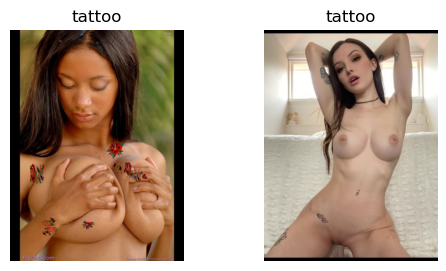

In [4]:
dls_crit = get_crit_dls(fnames, bs=batch_size, size=image_size)
dls_crit.show_batch()

# Create the Learner

In [5]:
loss_crit = AdaptiveLoss(nn.BCEWithLogitsLoss())

In [6]:
def create_crit_learner(dls, metrics):
    basename = os.path.basename(callback_saved_model)
    fname = callback_saved_model.parent.resolve()

    
    learner = Learner(dls,
                   gan_critic(),
                   metrics=metrics,
                   loss_func=loss_crit,
                   cbs=[
                       # Set things up so that we can resume a crashed training session
                       SaveModelCallback(with_opt=True, fname=basename, every_epoch=every_epoch),
                   ])
    # See if we need to restore the existing model    
    model_path = Path(f'{fname}/models/{basename}_{start_epoch}.pth')
    if model_path.exists() and start_epoch > 0:
        print(f"WARNING: Resuming existing model training from {model_path} at epoch {start_epoch}")
        learner.load(f'{basename}_{start_epoch}')

    return learner

In [7]:
learn_crit = create_crit_learner(dls_crit, accuracy_thresh_expand)

# Do the learning

In [8]:
# What callbacks do we want
cbs = []
csv_append = True
if (start_epoch == 0):
    cbs.append(ShowGraphCallback())
    csv_append = False # overwrite whatever is there since we are starting at the beginning
    
# Add a logger to write to csv
cbs.append(CSVLogger(fname='history-critic.csv', append=csv_append))
    
# Do the learning
learn_crit.fit_one_cycle(epocs,
                        #pct_start=0.3,
                        wd=wd,
                        start_epoch=start_epoch,
                        cbs=cbs
                       )

epoch,train_loss,valid_loss,accuracy_thresh_expand,time


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.75 GiB (GPU 0; 11.76 GiB total capacity; 4.16 GiB already allocated; 2.70 GiB free; 6.68 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

# Save the Model

In [ ]:
#save the model
deinked_gen_critic_file = f'./deinked-gen-critic-epocs{epocs}.pkl'
learn_crit.export(deinked_gen_critic_file)
print(f'Storing model {deinked_gen_critic_file}')

%store deinked_gen_critic_file